In [11]:
import os
import json
import glob
from tqdm import tqdm
import rasterio
import numpy as np
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt

In [4]:
BASE_PATH = r"C:\Users\Agando\Documents\Bachelorarbeit\DFC_Public_Dataset_ORIGINAL"

def get_majority_class(mask_path):
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
    flat = mask.flatten()
    counts = Counter(flat)
    majority_class = int(counts.most_common(1)[0][0])
    return majority_class

In [5]:
metadata = []

# Look through all ROI folders (e.g., ROIs0000_autumn)
roi_folders = [f for f in os.listdir(BASE_PATH) if f.startswith("ROIs")]

for roi_folder in roi_folders:
    roi_path = os.path.join(BASE_PATH, roi_folder)

    # Look for dfc_* subfolders inside this ROI folder
    dfc_folders = glob.glob(os.path.join(roi_path, "dfc_*"))
    
    for dfc_folder in dfc_folders:
        scene = os.path.basename(dfc_folder).replace("dfc_", "")
        dfc_files = glob.glob(os.path.join(dfc_folder, "*.tif"))

        for dfc_path in tqdm(dfc_files, desc=f"{scene} in {roi_folder}"):
            filename = os.path.basename(dfc_path)
            patch_id = filename  # or strip extension if preferred

            # Generate expected s1/s2 paths
            s1_path = os.path.join(roi_path, f"s1_{scene}", filename.replace("dfc", "s1"))
            s2_path = os.path.join(roi_path, f"s2_{scene}", filename.replace("dfc", "s2"))

            if not (os.path.exists(s1_path) and os.path.exists(s2_path)):
                print(f"[!] Missing s1/s2 for {patch_id}")
                continue

            try:
                majority_class = get_majority_class(dfc_path)
            except Exception as e:
                print(f"[!] Error reading {dfc_path}: {e}")
                continue

            metadata.append({
                "id": patch_id,
                "scene": scene,
                "roi_folder": roi_folder,
                "path_dfc": dfc_path,
                "path_s1": s1_path,
                "path_s2": s2_path,
                "majority_class": majority_class
            })

# Save metadata
with open("patch_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"\n✅ Saved metadata for {len(metadata)} patches.")

BandarAnzali in ROIs0000_autumn:   0%|          | 0/676 [00:00<?, ?it/s]

MexicoCity in ROIs0000_winter: 100%|██████████| 484/484 [00:07<00:00, 63.61it/s]


✅ Saved metadata for 6114 patches.


In [4]:
counts = Counter(combined_labels)
print("Samples per combined label:")
for label, count in counts.items():
    if count < 2:
        print(f"{label}: {count}")

Samples per combined label:
KippaRing|1: 1
KippaRing|6: 1
MexicoCity|3: 1


In [21]:
random.seed(42)

# Load metadata
with open("patch_metadata.json") as f:
    metadata = json.load(f)

# Group patches by scene
scene_groups = defaultdict(list)
for item in metadata:
    scene = item["scene"]
    scene_groups[scene].append(item)

# Initialize splits
train_ids, val_ids, test_ids = [], [], []

# Split each scene into 80% train, 10% val, 10% test
for scene, patches in scene_groups.items():
    random.shuffle(patches)
    n = len(patches)
    n_train = int(0.8 * n)
    n_val = int(0.1 * n)

    train_ids += [p["id"] for p in patches[:n_train]]
    val_ids   += [p["id"] for p in patches[n_train:n_train + n_val]]
    test_ids  += [p["id"] for p in patches[n_train + n_val:]]

# Save splits
with open("train_ids.json", "w") as f:
    json.dump(train_ids, f)
with open("val_ids.json", "w") as f:
    json.dump(val_ids, f)
with open("test_ids.json", "w") as f:
    json.dump(test_ids, f)

print(f"Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

Train: 4889 | Val: 609 | Test: 616



📊 Percentage Distribution (by Majority Class):
Class         All    Train      Val     Test
1           26.17    26.28    24.96    26.46
2            5.25     5.24     4.76     5.84
4            6.15     6.07     6.40     6.49
5            3.45     3.48     2.96     3.73
6           22.41    22.52    22.00    21.92
7            9.65     9.78     9.20     9.09
9            1.62     1.47     2.46     1.95
10          25.30    25.16    27.26    24.51


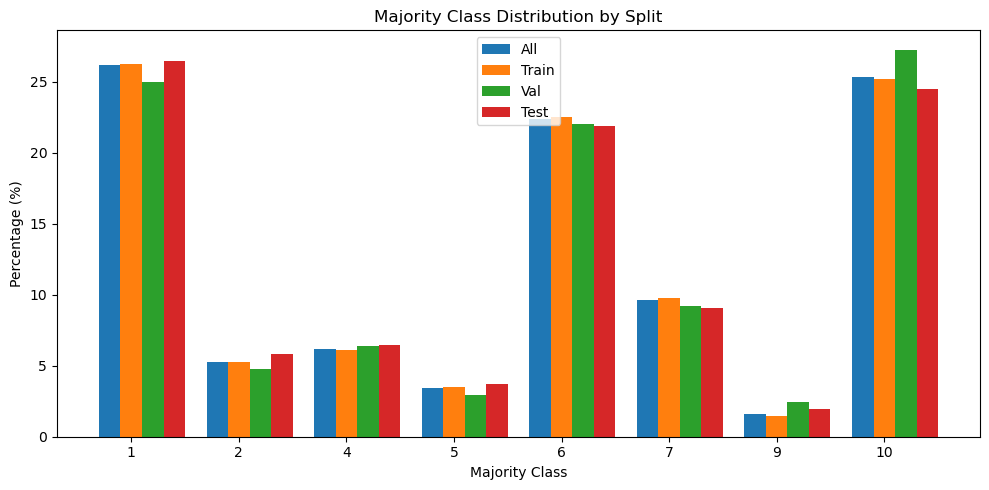

In [ ]:
####### MAJORITY CLASS DISTRIBUTION #######

# Load metadata
with open("patch_metadata.json") as f:
    metadata = json.load(f)

# Load split IDs
with open("train_ids.json") as f:
    train_ids = set(json.load(f))
with open("val_ids.json") as f:
    val_ids = set(json.load(f))
with open("test_ids.json") as f:
    test_ids = set(json.load(f))

# Build lookup: patch_id → majority_class
id_to_class = {item["id"]: item["majority_class"] for item in metadata}

# Collect majority classes per split
train_classes = [id_to_class[i] for i in train_ids if i in id_to_class]
val_classes = [id_to_class[i] for i in val_ids if i in id_to_class]
test_classes = [id_to_class[i] for i in test_ids if i in id_to_class]
all_classes = list(id_to_class.values())

# Count occurrences
counts = {
    "All": Counter(all_classes),
    "Train": Counter(train_classes),
    "Val": Counter(val_classes),
    "Test": Counter(test_classes),
}

# Get sorted unique class labels
labels = sorted(set(all_classes))

# Convert counts to percentages
percentages = {}
for split, counter in counts.items():
    total = sum(counter.values())
    percentages[split] = {label: (counter.get(label, 0) / total) * 100 for label in labels}

# Print percentage distribution
print("\n📊 Percentage Distribution (by Majority Class):")
print(f"{'Class':<8} {'All':>8} {'Train':>8} {'Val':>8} {'Test':>8}")
for label in labels:
    a = percentages["All"].get(label, 0)
    t = percentages["Train"].get(label, 0)
    v = percentages["Val"].get(label, 0)
    s = percentages["Test"].get(label, 0)
    print(f"{label:<8} {a:8.2f} {t:8.2f} {v:8.2f} {s:8.2f}")

# Optional: plot as bar chart
fig, ax = plt.subplots(figsize=(10, 5))
width = 0.2
x = range(len(labels))
for i, split in enumerate(["All", "Train", "Val", "Test"]):
    heights = [percentages[split].get(label, 0) for label in labels]
    ax.bar([xi + i * width for xi in x], heights, width=width, label=split)

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(labels)
ax.set_xlabel("Majority Class")
ax.set_ylabel("Percentage (%)")
ax.set_title("Majority Class Distribution by Split")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
####### SCENE DISTRIBUTION #######